## Code to compare SED results to initial input spectra & photometry

This is how I initially get the SED plotted and loaded. 

In [98]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import astropy.units as u
from synphot import SourceSpectrum, Observation, SpectralElement
from synphot.models import Empirical1D

In [99]:
COCO_PATH="/Users/ravkaur/Desktop/research/kilonova-SED/PyCoCo_templates/"
FILTER_PATH = COCO_PATH+"Inputs/Filters/KN_Filters_clean/"

#### Run this cell to get all the functions

In [100]:
def create_lookup_table(data_dir, wavelength_range=None, wavelength_bins=10000):
    """
    Load spectra from files, interpolate onto a common wavelength grid,
    and create both a DataFrame lookup table and a list of raw spectra.

    Parameters
    ----------
    data_dir : str
        Path to the directory containing spectra files.
    wavelength_range : tuple, optional
        (min, max) wavelength range for interpolation.
        If None, uses min/max across all input spectra.
    wavelength_bins : int
        Number of bins for common wavelength interpolation.

    Returns
    -------
    lookup_table : pd.DataFrame
        Interpolated flux grid (times x wavelengths).
    days_from_start : np.ndarray
        Time in days from the first MJD.
    common_wavelengths : np.ndarray
        Wavelength grid for interpolation.
    spectra_list : list of tuples
        Each entry is (time, wavelength_array, flux_array)
        with the raw values from the input file (no interpolation, no NaNs).
    """
    import os
    import numpy as np
    import pandas as pd

    # Collect all spectra files
    spectra_files = sorted([f for f in os.listdir(data_dir) if f.endswith(".txt")])

    mjds = []
    wavelengths = []
    fluxes = []
    spectra_list = []

    for file in spectra_files:
        # Extract the MJD from the filename (assuming it starts with MJD)
        mjd = float(file.split("_")[0])
        mjds.append(mjd)

        # Load the data (assuming 3 columns: wavelength, flux, flux error)
        data = np.loadtxt(os.path.join(data_dir, file))
        wl = data[:, 0]
        fl = data[:, 1]

        wavelengths.append(wl)
        fluxes.append(fl)

        # Save raw spectrum (shift to relative days later)
        spectra_list.append((mjd, wl, fl))

    mjds = np.array(mjds)
    fluxes = np.array(fluxes, dtype=object)

    # Define common wavelength grid
    all_wavelengths = np.concatenate(wavelengths)
    wl_min = wavelength_range[0] if wavelength_range else np.nanmin(all_wavelengths)
    wl_max = wavelength_range[1] if wavelength_range else np.nanmax(all_wavelengths)
    common_wavelengths = np.linspace(wl_min, wl_max, wavelength_bins)

    # Interpolate flux onto the common wavelength grid
    fluxes_interpolated = []
    for i in range(len(fluxes)):
        # safer to use 0.0 outside, not NaN
        flux_interp = np.interp(common_wavelengths, wavelengths[i], fluxes[i],
                                left=0.0, right=0.0)
        fluxes_interpolated.append(flux_interp)

    fluxes_interpolated = np.array(fluxes_interpolated)

    # Subtract the minimum MJD to get days from start
    days_from_start = mjds - mjds.min()

    # Build DataFrame
    lookup_table = pd.DataFrame(
        fluxes_interpolated,
        index=days_from_start,          # Time as index
        columns=common_wavelengths      # Wavelength as columns
    )

    # Update spectra_list so times are days-from-start too
    spectra_list = [(mjd - mjds.min(), wl, fl) for mjd, wl, fl in spectra_list]

    return lookup_table, days_from_start, common_wavelengths, spectra_list

def synthetic_lightcurve(filter_file, system="abmag",
                         lookup_table=None, common_wavelengths=None,
                         spectra_list=None):
    """
    Compute a synthetic light curve by integrating spectra through a filter.

    Inputs (provide ONE of the two data pathways)
    --------------------------------------------
    - spectra_list: list of (time, wavelength, flux) tuples.
        * time: usually DAYS from start (float)
        * wavelength: Å array (monotonic)
        * flux: F_lambda array in erg s^-1 cm^-2 Å^-1
    - OR
    - lookup_table + common_wavelengths:
        * lookup_table: DataFrame [times x wavelengths] of F_lambda
        * common_wavelengths: 1D Å array

    Parameters
    ----------
    filter_file : str
        Two-column file (wavelength[Å], transmission[0–1]).
    system : str
        "flam", "abmag", "stmag", "vegamag", or "countrate".

    Returns
    -------
    times : np.ndarray
        Synthetic times (as provided: relative days or absolute MJD).
    lc : np.ndarray
        Synthetic values in the requested system.
    """
    filt_wave, filt_thru = np.loadtxt(filter_file, unpack=True)
    bandpass = SpectralElement(Empirical1D, points=filt_wave * u.AA, lookup_table=filt_thru)

    times, lc = [], []

    if spectra_list is not None:
        for (t, wl, fl) in spectra_list:
            m = np.isfinite(fl)
            if m.sum() == 0:
                times.append(t); lc.append(np.nan); continue
            src = SourceSpectrum(Empirical1D, points=wl[m] * u.AA,
                                 lookup_table=fl[m] * u.erg/u.s/(u.cm**2)/u.AA)
            obs = Observation(src, bandpass, force="taper")
            val = obs.countrate().value if system == "countrate" else obs.effstim(system).value
            times.append(t); lc.append(val)

    elif lookup_table is not None and common_wavelengths is not None:
        for i, t in enumerate(lookup_table.index):
            fl = lookup_table.iloc[i].values.astype(float)
            m = np.isfinite(fl)
            if m.sum() == 0:
                times.append(t); lc.append(np.nan); continue
            src = SourceSpectrum(Empirical1D, points=common_wavelengths[m] * u.AA,
                                 lookup_table=fl[m] * u.erg/u.s/(u.cm**2)/u.AA)
            obs = Observation(src, bandpass, force="taper")
            val = obs.countrate().value if system == "countrate" else obs.effstim(system).value
            times.append(t); lc.append(val)
    else:
        raise ValueError("Provide either spectra_list OR (lookup_table + common_wavelengths).")

    return np.array(times), np.array(lc)


def _auto_align_times(syn_times, obs_mjd, reference_mjd=None, syn_times_are_mjd=None):
    """
    Align observed MJD and synthetic times onto a common 'days since t0' axis.

    Heuristics:
      - If syn_times_are_mjd is provided, use it.
      - Else treat syn times as MJD if median(syn_times) > 10000.
      - If syn times are relative (days), set t0 = obs_mjd.min().
      - If syn times are absolute MJD, set t0 = min(obs_mjd.min(), syn_times.min()).
      - If reference_mjd is given, use that as t0.
    """
    syn_times = np.asarray(syn_times, dtype=float)
    obs_mjd = np.asarray(obs_mjd, dtype=float)

    if reference_mjd is not None:
        t0 = float(reference_mjd)
        # If user provides t0, assume syn_times are relative unless they look like MJD
        if syn_times_are_mjd is None:
            syn_times_are_mjd = (np.nanmedian(syn_times) > 10000)
    else:
        if syn_times_are_mjd is None:
            syn_times_are_mjd = (np.nanmedian(syn_times) > 10000)

        if syn_times_are_mjd:
            t0 = np.nanmin([np.nanmin(obs_mjd), np.nanmin(syn_times)])
        else:
            t0 = np.nanmin(obs_mjd)

    obs_time = obs_mjd - t0
    syn_time = syn_times - (t0 if syn_times_are_mjd else 0.0)
    return syn_time, obs_time, t0

def compare_lightcurves_mag(filter_file, data_file, 
                            lookup_table=None, common_wavelengths=None,
                            spectra_list=None, system="abmag", mjd0=None):
    """
    Compare synthetic lightcurve in AB mag to observed photometry (in mags).
    """
    # --- synthetic lightcurve ---
    syn_times, syn_mags = synthetic_lightcurve(
        filter_file, system=system,
        lookup_table=lookup_table,
        common_wavelengths=common_wavelengths,
        spectra_list=spectra_list
    )

    # --- observed photometry ---
    df = pd.read_csv(data_file)  # comma is default

    # Extract bandname from filter file (e.g., "Swope_g.dat" -> "Swope_g")
    bandname = os.path.basename(filter_file).replace(".dat", "")
    
    obs = df[df["band"] == bandname].copy()
    if obs.empty:
        raise ValueError(f"No photometry found for band '{bandname}' in {data_file}")

    # time axis: relative to chosen mjd0
    if mjd0 is None:
        mjd0 = obs["MJD"].min()  # <-- FIXED

    obs["time"] = obs["MJD"] - mjd0
    syn_times = syn_times - 0.0  # synthetic times are already days-from-start

    # --- plotting ---
    plt.figure(figsize=(7,5))
    plt.errorbar(obs["time"], obs["Mag"], yerr=obs["Mag_err"],
                 fmt="o", label="Observed", color="tab:blue")
    plt.plot(syn_times, syn_mags, "-", label="Synthetic", color="tab:orange")

    plt.xlabel("Time since {:.2f} MJD (days)".format(mjd0))
    plt.ylabel("AB mag")
    plt.title(f"Lightcurve in {bandname}")
    plt.gca().invert_yaxis()  # brighter = up
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_spectrum(time_from_start, lookup_table, wavelengths):
    """
    Plot a spectrum (flux vs wavelength) for a given time.
    """
    # Find the closest time in the DataFrame
    closest_time = lookup_table.index[np.argmin(np.abs(lookup_table.index - time_from_start))]
    flux = lookup_table.loc[closest_time]

    # Plot the spectrum
    plt.figure(figsize=(8, 5))
    plt.plot(wavelengths, flux, label=f"Time = {closest_time:.2f} days")
    plt.xlabel("Wavelength (Å)")
    plt.ylabel(r"Flux (erg s$^{-1}$ cm$^{-2}$ Å$^{-1}$)")
    plt.title("Spectrum at Time {:.2f} days".format(closest_time))
    plt.legend()
    plt.grid()
    plt.show()


def plot_lightcurve(wavelength, lookup_table):
    """
    Plot a light curve (flux vs time) for a given wavelength.
    """
    # Find the closest wavelength in the DataFrame
    closest_wavelength = lookup_table.columns[np.argmin(np.abs(lookup_table.columns - wavelength))]
    flux = lookup_table[closest_wavelength]

    # Plot the light curve
    plt.figure(figsize=(8, 5))
    plt.scatter(lookup_table.index, flux, label=f"Wavelength = {closest_wavelength:.2f} Å")
    plt.xlabel("Time (days from start)")
    plt.ylabel(r"Flux (erg s$^{-1}$ cm$^{-2}$ Å$^{-1}$)")
    plt.title("Lightcurve at Wavelength {:.2f} Å".format(closest_wavelength))
    plt.legend()
    plt.grid()
    plt.show()


def plot_sed_evolution(
    lookup_table,
    common_wavelengths,
    days_from_start,
    vmin=None,
    vmax=None
):
    """
    Create a 2D plot of spectral density evolution (time vs wavelength vs flux).

    Parameters
    ----------
    lookup_table : pd.DataFrame
        Flux values with time as index and wavelengths as columns.
    common_wavelengths : np.ndarray
        The wavelength grid used for interpolation.
    days_from_start : np.ndarray
        Time in days from the first detection.
    vmin, vmax : float, optional
        Min/max flux values for color scaling. If None, determined from the data.
    """
    import matplotlib.pyplot as plt
    from matplotlib.colors import LogNorm
    import numpy as np

    flux_values = lookup_table.values

    # if not provided, compute automatically
    if vmin is None:
        vmin = np.nanmin(flux_values[flux_values > 0])  # smallest positive flux
    if vmax is None:
        vmax = np.nanmax(flux_values)

    plt.figure(figsize=(10, 6))
    plt.imshow(
        flux_values.T,
        aspect='auto',
        extent=[days_from_start.min(), days_from_start.max(),
                common_wavelengths.min(), common_wavelengths.max()],
        origin='lower',
        cmap='viridis',
        norm=LogNorm(vmin=vmin, vmax=vmax)
    )
    plt.colorbar(label=r"Flux (erg s$^{-1}$ cm$^{-2}$ Å$^{-1}$)")
    plt.xlabel("Days from first detection")
    plt.ylabel("Wavelength (Å)")
    plt.title("SED Evolution")
    plt.show()

def compare_sed_and_original_spectrum(
    mjd_query,
    lookup_table,
    wavelengths,
    mjd0,
    list_file,
    original_spec_dir=None,
    ax=None,
    mode="original",
    time_window=0.,
    z = 0.00984  # tolerance for including multiple spectra
):
    """
    Plot SED spectrum and original or smoothed input spectrum at the closest time 
    to mjd_query. If time_window > 0, plot all spectra within ±time_window of mjd_query.
    """
    import matplotlib.pyplot as plt
    import os
    import numpy as np

    # --- SED spectrum ---
    sed_time = mjd_query - mjd0
    closest_sed_time = lookup_table.index[np.argmin(np.abs(lookup_table.index - sed_time))]
    sed_flux = lookup_table.loc[closest_sed_time].values

    # --- Choose list and directory based on mode ---
    if mode == "smoothed":
        list_file = list_file.replace("1_spec_lists_original", "2_spec_lists_smoothed")
        if original_spec_dir is None:
            original_spec_dir = "/Users/ravkaur/Desktop/research/kilonova-SED/PyCoCo_templates/Inputs/Spectroscopy/2_spec_smoothed"
    else:
        if original_spec_dir is None:
            original_spec_dir = "/Users/ravkaur/Desktop/research/kilonova-SED/PyCoCo_templates/Inputs/Spectroscopy/1_spec_original"

    # --- Load list of spectra ---
    orig_paths, orig_mjds = [], []
    with open(list_file) as f:
        for line in f:
            if line.strip() == "" or line.startswith("#"):
                continue
            parts = line.split()
            if mode == "smoothed":
                if len(parts) < 3:
                    continue
                try:
                    orig_mjds.append(float(parts[0]))
                    orig_paths.append(parts[2])
                except Exception:
                    continue
            else:
                if len(parts) < 3:
                    continue
                try:
                    orig_paths.append(parts[0])
                    orig_mjds.append(float(parts[-1]))
                except Exception:
                    continue
    if not orig_paths or not orig_mjds:
        print(f"No valid spectra found in {list_file}")
        return
    orig_mjds = np.array(orig_mjds)

    # --- Select spectra ---
    if time_window > 0:
        idxs = np.where(np.abs(orig_mjds - mjd_query) <= time_window)[0]
        if len(idxs) == 0:
            idxs = [np.argmin(np.abs(orig_mjds - mjd_query))]
    else:
        idxs = [np.argmin(np.abs(orig_mjds - mjd_query))]

    # --- Plot ---
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 5))

    # Plot SED first
    ax.plot(
        wavelengths, sed_flux,
        label=f"SED (t={closest_sed_time + mjd0:.6f} MJD)",  # full precision
        color="black",
        alpha=0.75
    )

    label = "Smoothed" if mode == "smoothed" else "Original"

    # Color cycle for multiple spectra
    color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']

    for j, idx in enumerate(idxs):
        orig_path = orig_paths[idx]
        orig_mjd = orig_mjds[idx]

        # --- Fix local path if needed ---
        if orig_path.startswith("/data/1_spec_original/") or orig_path.startswith("/data/2_spec_smoothed/"):
            if mode == "smoothed":
                local_base = "/Users/ravkaur/Desktop/research/kilonova-SED/PyCoCo_templates/Inputs/Spectroscopy/2_spec_smoothed"
                orig_path = os.path.join(local_base, orig_path.replace("/data/2_spec_smoothed/", ""))
            else:
                local_base = "/Users/ravkaur/Desktop/research/kilonova-SED/PyCoCo_templates/Inputs/Spectroscopy/1_spec_original"
                orig_path = os.path.join(local_base, orig_path.replace("/data/1_spec_original/", ""))
        elif not orig_path.startswith("/"):
            orig_path = os.path.join(original_spec_dir, orig_path)
        orig_path = os.path.expanduser(orig_path)

        # --- Load spectrum ---
        try:
            orig_data = np.loadtxt(orig_path)
            orig_wl = orig_data[:, 0]
            orig_flux = orig_data[:, 1]
        except Exception as e:
            print(f"Could not load spectrum: {orig_path}\n{e}")
            continue
        
        if z > 0.0:
            orig_wl = orig_wl / (1 + z)
            orig_flux = orig_flux * (1 + z)
        
        # --- Plot spectrum ---
        ax.plot(
            orig_wl, orig_flux,
            label=f"{label} (t={orig_mjd:.6f} MJD)",  # full precision
            color=color_cycle[j % len(color_cycle)],
            alpha=0.8
        )
    ax.set_ylim(0, 8e-17)

    ax.set_xlabel("Wavelength (Å)")
    ax.set_ylabel(r"Flux (erg s$^{-1}$ cm$^{-2}$ Å$^{-1}$)")
    ax.set_title(f"SED vs {label} Spectrum(s) near {mjd_query:.2f} MJD")
    ax.legend()
    ax.grid()
    plt.show()

In [101]:
data_dir = "/Users/ravkaur/Desktop/research/kilonova-SED/PyCoCo_templates/Outputs/AT2017gfo/FINAL_spectra_2dim/as_observed"

In [102]:
lookup_table, days_from_start, common_wavelengths, spectra_list = create_lookup_table(data_dir)

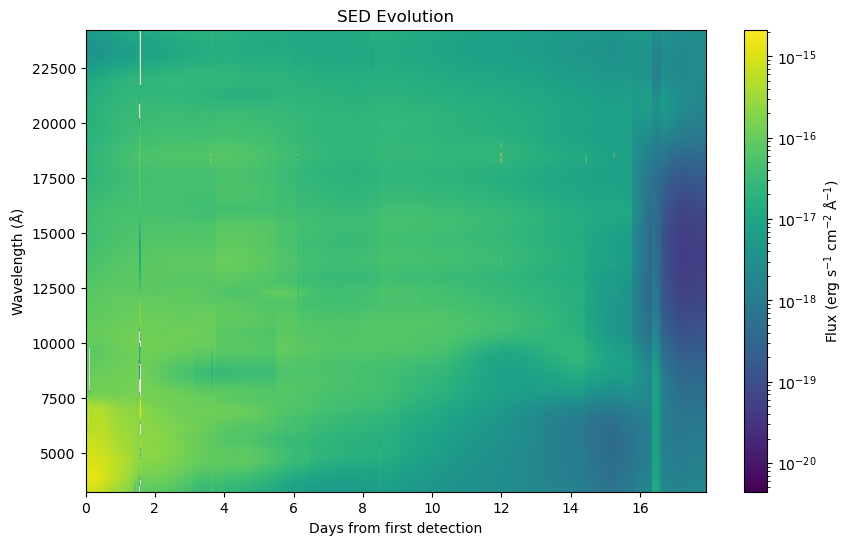

In [103]:
plot_sed_evolution(lookup_table, common_wavelengths, days_from_start)

  points: [7851.145 7852.333 7853.422 ... 9802.642 9803.731 9804.92 ]
  lookup_table: [-8.08759142e-08 -2.95436616e-07 -4.91328453e-07 ... -2.95288496e-05
 -2.94760106e-05 -2.94179063e-05] [synphot.models]
  points: [ 3257.341  3296.951  3336.561  3376.171  3415.782  3455.392  3495.002
  3534.612  7772.908  7812.518  7852.128  7891.738  7931.349  7970.959
  8010.569  8050.179  8089.789  8129.4    8169.01   8208.62   8248.23
  8287.841  8327.451  8367.061  9040.435  9080.045 10030.69  10070.3
 10109.91  10149.52  10189.13  10228.74  10268.35  10307.96  10347.57
 10387.18  10426.79  10466.4   10506.01  10545.62  20210.52  20250.13
 20289.74  20329.35  20368.96  20408.57  20448.18  20487.79  20527.4
 20567.01  20606.62  20646.23  20685.84  20725.45  20765.06  20804.67
 20844.28 ]
  lookup_table: [-5.50868025e-06 -4.95701173e-06 -4.36273162e-06 -3.72214770e-06
 -3.03055098e-06 -2.28206813e-06 -1.46956709e-06 -5.84585777e-07
 -1.09614098e-06 -4.38301875e-06 -6.77119726e-06 -8.35974152e-06
 

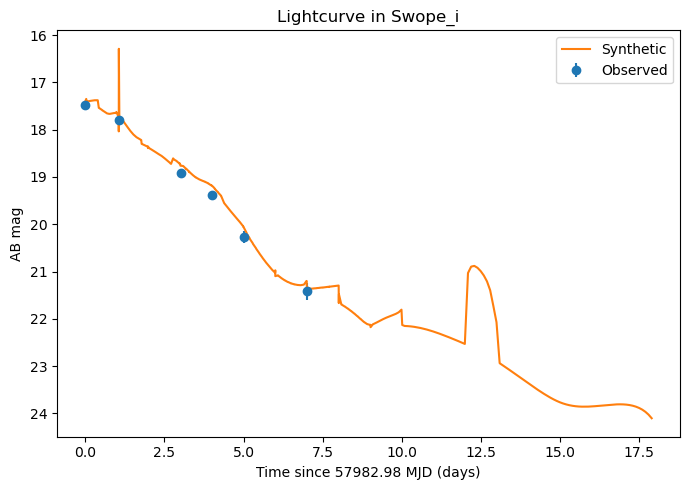

In [104]:
compare_lightcurves_mag(
    FILTER_PATH+"Swope_i.dat",
    COCO_PATH+"Inputs/Photometry/1_LCs_flux_raw/AT2017gfo.dat",
    spectra_list=spectra_list,
    system="abmag"
)

In [75]:
df = pd.read_csv(COCO_PATH+"Inputs/Photometry/1_LCs_flux_raw/AT2017gfo.dat")
obs = df[df["band"] == 'Swope_i'].copy()

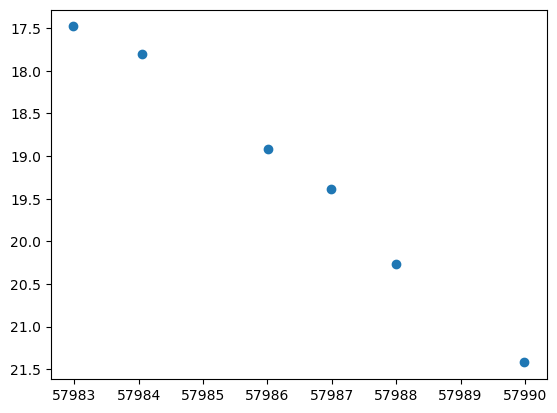

In [76]:
plt.scatter(obs['MJD'], obs['Mag'])
plt.gca().invert_yaxis()

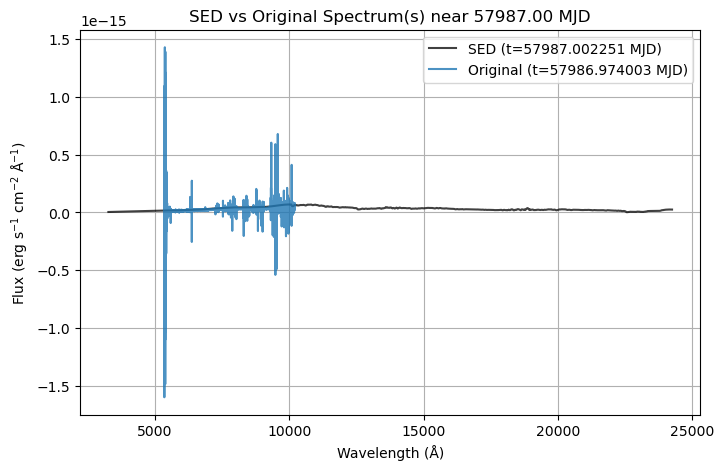

In [85]:
# For original
compare_sed_and_original_spectrum(
    mjd_query=57987.0,
    lookup_table=lookup_table,
    wavelengths=common_wavelengths,
    mjd0=57983.01825,
    list_file="/Users/ravkaur/Desktop/research/kilonova-SED/PyCoCo_templates/Inputs/Spectroscopy/1_spec_lists_original/AT2017gfo.list",
    mode="original"
)

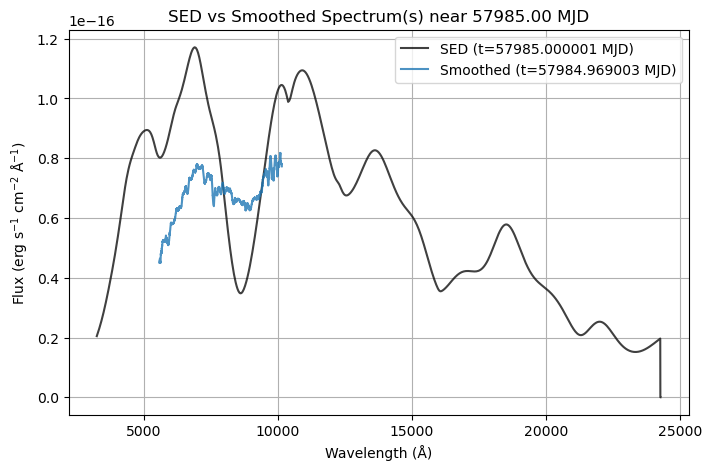

In [81]:
# For smoothed
compare_sed_and_original_spectrum(
    mjd_query=57985.0,
    lookup_table=lookup_table,
    wavelengths=common_wavelengths,
    mjd0=57983.01825,
    list_file="/Users/ravkaur/Desktop/research/kilonova-SED/PyCoCo_templates/Inputs/Spectroscopy/1_spec_lists_original/AT2017gfo.list",
    mode="smoothed"
)

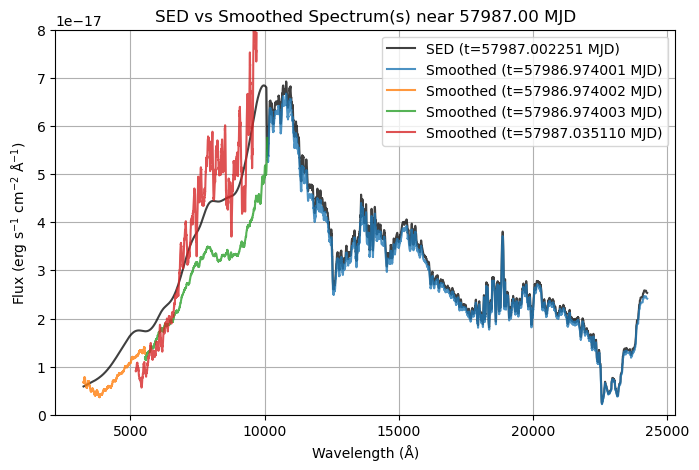

In [106]:
compare_sed_and_original_spectrum(
    mjd_query=57987.0,
    lookup_table=lookup_table,
    wavelengths=common_wavelengths,
    mjd0=57983.01825,
    list_file="/Users/ravkaur/Desktop/research/kilonova-SED/PyCoCo_templates/Inputs/Spectroscopy/1_spec_lists_original/AT2017gfo.list",
    mode='smoothed',
    time_window=0.5  # will include all spectra within ±0.5 days
)

Could not load spectrum: /Users/ravkaur/Desktop/research/kilonova-SED/PyCoCo_templates/Inputs/Spectroscopy/1_spec_original/AT2017gfo/57987.03511_LDSS3_Magellan.dat
could not convert string 'wavelength' to float64 at row 0, column 1.


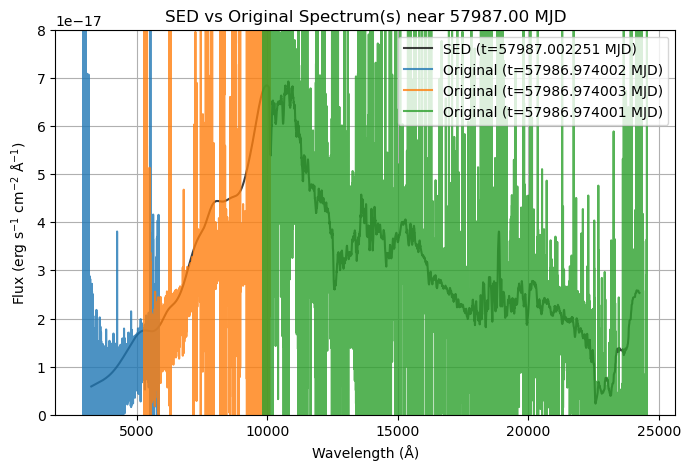

In [107]:
compare_sed_and_original_spectrum(
    mjd_query=57987.0,
    lookup_table=lookup_table,
    wavelengths=common_wavelengths,
    mjd0=57983.01825,
    list_file="/Users/ravkaur/Desktop/research/kilonova-SED/PyCoCo_templates/Inputs/Spectroscopy/1_spec_lists_original/AT2017gfo.list",
    mode='original',
    time_window=0.5 ) # will include all spectra within ±0.5 days

## testing lightcurve function that plots multiple at once

In [64]:
def compare_lightcurves_mag(
    filter_files,
    data_file,   # a single photometry file with all filters
    lookup_table=None,
    common_wavelengths=None,
    spectra_list=None,
    system="abmag",
    mjd0=None
):
    """
    Compare synthetic lightcurves in AB mag to observed photometry, 
    for one or multiple filters.

    Parameters
    ----------
    filter_files : str or list of str
        Filter transmission curve files (e.g., ["Swope_g.dat", "FourStar_H.dat"]).
    data_file : str
        CSV with observed photometry (must contain 'MJD','Mag','Mag_err','band').
    lookup_table, common_wavelengths, spectra_list : see synthetic_lightcurve
    system : str
        Magnitude system ("abmag", "vegamag", etc.).
    mjd0 : float, optional
        Reference MJD. If None, uses the earliest observed MJD across all filters.
    """
    import matplotlib.pyplot as plt
    import numpy as np
    import pandas as pd
    import os

    # normalize input
    if isinstance(filter_files, str):
        filter_files = [filter_files]

    # load observed data
    df = pd.read_csv(data_file)

    # decide mjd0 if not provided
    if mjd0 is None:
        mjd0 = df["MJD"].min()

    fig, ax = plt.subplots(figsize=(8, 6))
    color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']

    for k, filter_file in enumerate(filter_files):
        # band name inferred from filter file name
        bandname = os.path.basename(filter_file).replace(".dat", "")

        # synthetic lightcurve for this filter
        syn_times, syn_mags = synthetic_lightcurve(
            filter_file,
            system=system,
            lookup_table=lookup_table,
            common_wavelengths=common_wavelengths,
            spectra_list=spectra_list
        )
        syn_times = syn_times  # already in days-from-start

        # pick a color for this filter
        color = color_cycle[k % len(color_cycle)]

        # observed data for this filter
        obs = df[df["band"] == bandname].copy()
        if obs.empty:
            print(f"⚠️ No photometry found for band '{bandname}' in {data_file}")
            continue
        obs["time"] = obs["MJD"] - mjd0

        # plot observed
        ax.errorbar(
            obs["time"], obs["Mag"], yerr=obs["Mag_err"],
            fmt="o", label=f"Obs {bandname}",
            color=color, alpha=0.9
        )

        # plot synthetic
        ax.plot(
            syn_times, syn_mags,
            "-", label=f"SED {bandname}",
            color=color, lw=2, alpha=0.7
        )

    ax.set_xlabel(f"Time since {mjd0:.2f} MJD (days)")
    ax.set_ylabel("AB mag")
    ax.set_title("Observed vs Synthetic Lightcurves")
    ax.invert_yaxis()  # brighter = up
    ax.legend()
    fig.tight_layout()
    plt.show()

In [65]:
compare_lightcurves_mag(
    filter_files=["Swope_i.dat", "Swope_w.dat", "FourStar_H.dat"],
    data_file="photometry.csv",
    lookup_table=lookup_table,
    common_wavelengths=common_wavelengths,
    spectra_list=spectra_list,
    system="abmag"
)

FileNotFoundError: [Errno 2] No such file or directory: 'photometry.csv'

In [97]:
import numpy as np

wavelengths = np.arange(1500, 25001, 10)  # 1500–25000 Å in steps of 100
phases = np.arange(0, 201, 1)              # 0–200 days
flat_value = 1.0

with open("prior_flat.txt", "w") as f:
    for wl in wavelengths:
        for ph in phases:
            f.write(f"{wl:.1f},{ph:.1f},{flat_value:.2f}\n")